# Pharma Sales Forecasting using Machine Learning

## Project Overview

This project builds an end-to-end machine learning pipeline to forecast monthly pharmaceutical sales.

The workflow includes:

- Data extraction and preprocessing
- Feature engineering
- Exploratory Data Analysis (EDA)
- Time-series train/test split
- Baseline forecasting models
- XGBoost forecasting model
- Hyperparameter optimization
- Model evaluation
- Business insights

## Dataset

The dataset contains monthly pharmaceutical sales across multiple drug categories from 2014–2019.

## Objective

Predict future monthly sales using historical sales and engineered time-series features while preventing data leakage.


In [2]:
import os
import sys
import warnings

warnings.filterwarnings("ignore")

# Move notebook to project root
os.chdir("..")

project_root = os.getcwd()

if project_root not in sys.path:
    sys.path.insert(0, project_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.features.feature_engineering import FeatureEngineering
from src.forecasting.forecasting_pipeline import ForecastingPipeline
from src.forecasting.baseline_models import BaselineModels
from src.forecasting.xgboost_trainer import XGBoostTrainer
from src.forecasting.model_optimizer import ModelOptimizer
from src.forecasting.metrics import ForecastMetrics

print("Project initialized successfully.")

Project initialized successfully.


In [3]:
import os
import sys

project_root = r"C:\Users\U1109200\Downloads\INTERN_TASK_REPO\Dummy_Project_E2E\data-pipeline"

os.chdir(project_root)

if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(os.getcwd())

C:\Users\U1109200\Downloads\INTERN_TASK_REPO\Dummy_Project_E2E\data-pipeline


In [4]:
import os

print("Current Directory:")
print(os.getcwd())

print("\nData folder exists:")
print(os.path.exists("data"))

print("\nProcessed folder exists:")
print(os.path.exists("data/processed"))

print("\nCSV exists:")
print(os.path.exists("data/processed/pharma_sales_processed.csv"))

Current Directory:
C:\Users\U1109200\Downloads\INTERN_TASK_REPO\Dummy_Project_E2E\data-pipeline

Data folder exists:
True

Processed folder exists:
True

CSV exists:
True


In [5]:
pipeline = ForecastingPipeline()

df = pipeline.load_data()

print(df.shape)

display(df.head())

(560, 3)


,date,category,sales_units
0,2014-01-31,M01AB,127.69
1,2014-02-28,M01AB,133.32
2,2014-03-31,M01AB,137.44
3,2014-04-30,M01AB,113.10
4,2014-05-31,M01AB,101.79


In [6]:
print("="*60)
print("DATASET OVERVIEW")
print("="*60)

print("\nShape")
print(df.shape)

print("\nColumns")
display(df.columns.to_frame())

print("\nData Types")
display(df.dtypes.to_frame())

print("\nSummary Statistics")
display(df.describe())

print("\nMissing Values")
display(df.isnull().sum().to_frame())

print("\nDuplicate Rows :", df.duplicated().sum())

print("\nCategories")

print(sorted(df.category.unique()))

DATASET OVERVIEW

Shape
(560, 3)

Columns


,0
date,date
category,category
sales_units,sales_units



Data Types


,0
date,object
category,object
sales_units,float64



Summary Statistics


,sales_units
count,560.000000
mean,226.046025
std,290.422593
min,0.000000
25%,88.100000
50%,132.474500
75%,220.500000
max,1856.815000



Missing Values


,0
date,0
category,0
sales_units,0



Duplicate Rows : 0

Categories
['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']


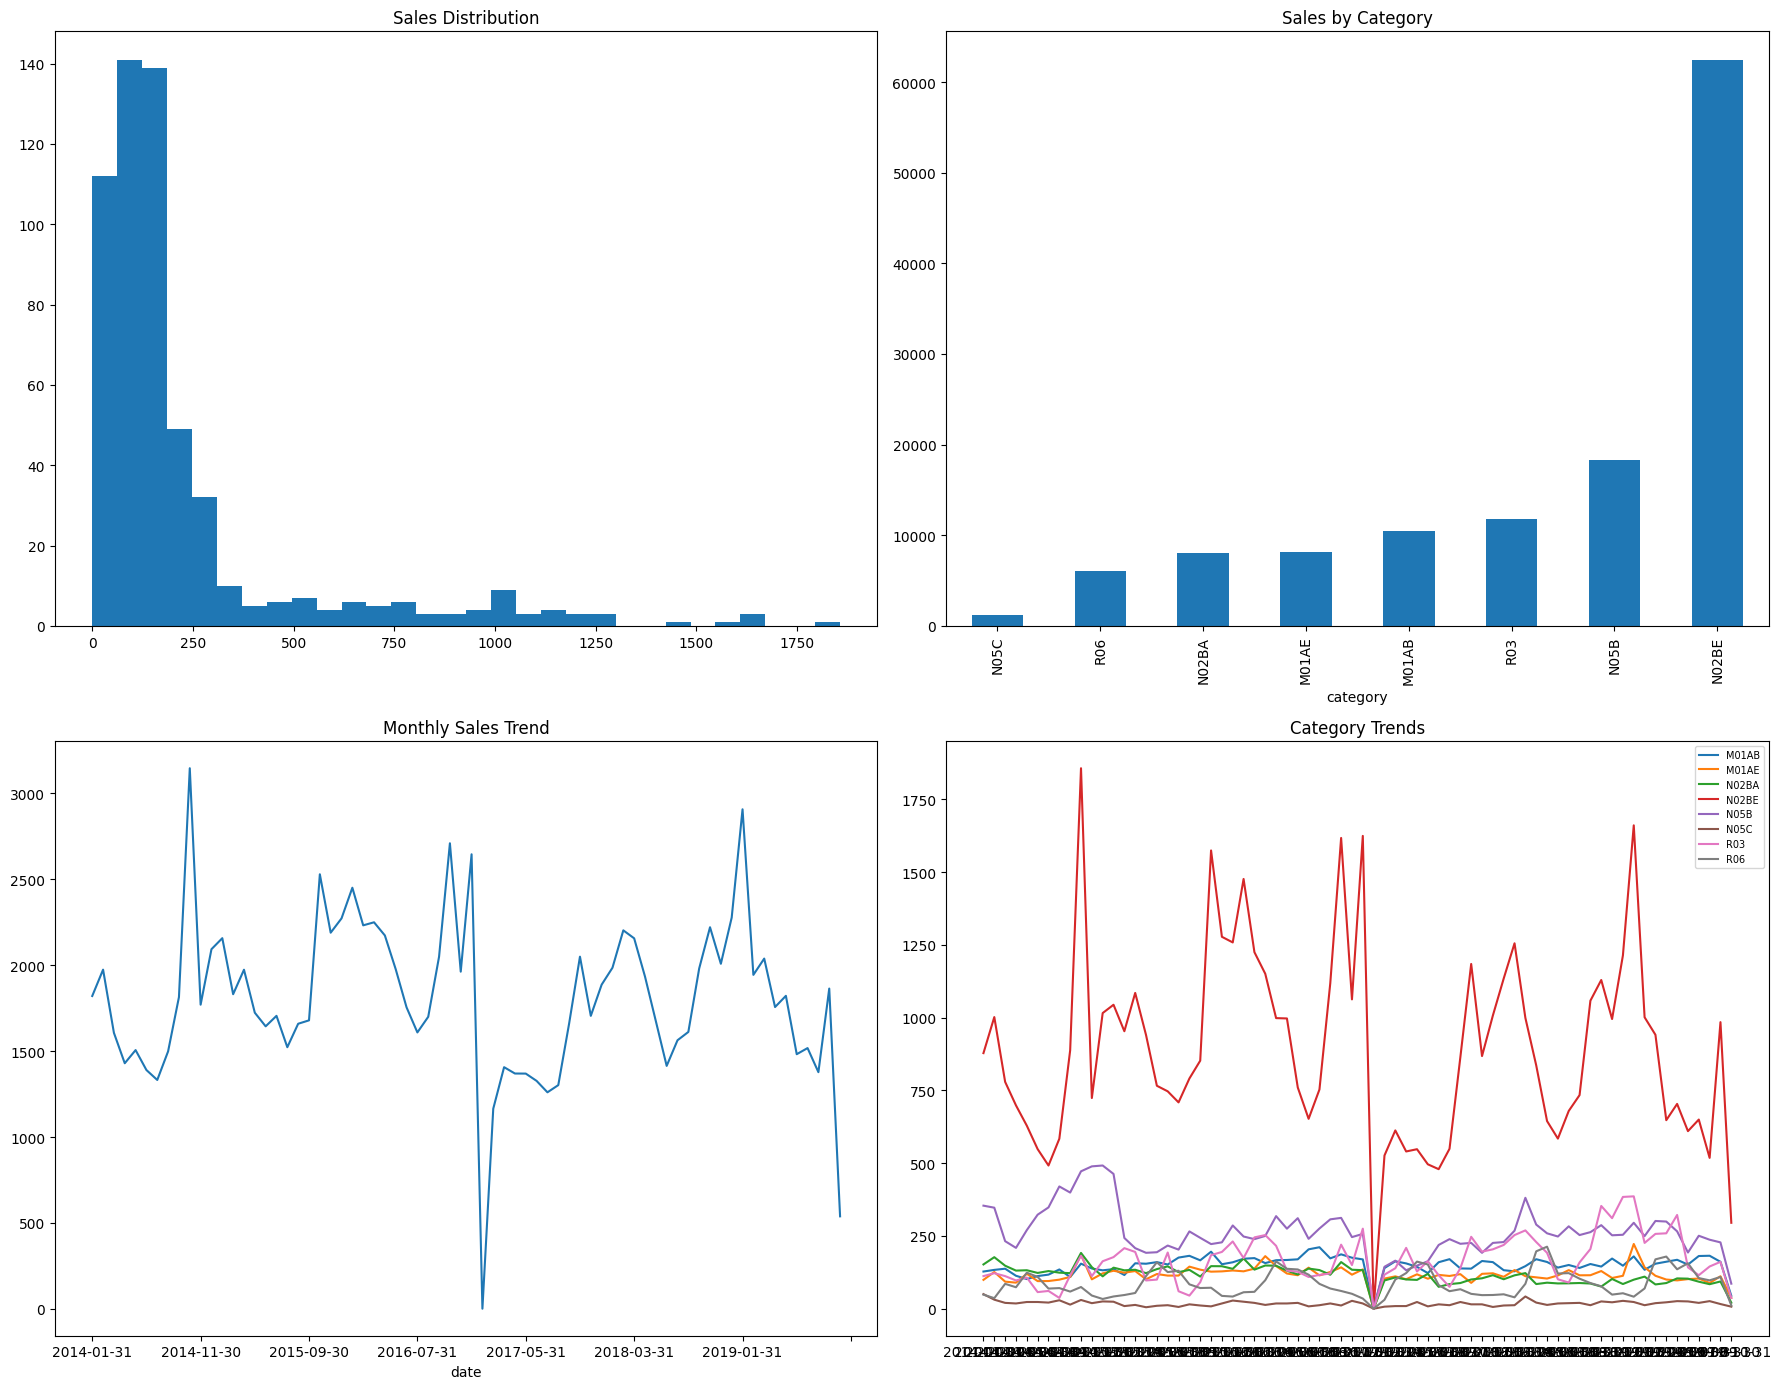

In [7]:
fig = plt.figure(figsize=(18,14))

# Histogram
plt.subplot(2,2,1)

plt.hist(df["sales_units"], bins=30)

plt.title("Sales Distribution")

# Category Sales

plt.subplot(2,2,2)

(
    df.groupby("category")["sales_units"]
    .sum()
    .sort_values()
).plot(kind="bar")

plt.title("Sales by Category")

# Monthly Trend

plt.subplot(2,2,3)

(
    df.groupby("date")["sales_units"]
    .sum()
).plot()

plt.title("Monthly Sales Trend")

# Category Trend

plt.subplot(2,2,4)

for category in df.category.unique():

    temp = df[df.category==category]

    plt.plot(
        temp.date,
        temp.sales_units,
        label=category
    )

plt.legend(fontsize=7)

plt.title("Category Trends")

plt.tight_layout()

plt.show()

## Load the Dataset

In this section, we load the processed pharmaceutical sales dataset that was generated by the ETL pipeline. This dataset serves as the input for feature engineering and subsequent forecasting tasks.

In [8]:
feature_df = pipeline.create_features(df)

print("Feature Dataset Shape")

print(feature_df.shape)

display(feature_df.head())

print("\nMissing Values")

display(feature_df.isnull().sum())

feature_df = feature_df.dropna().reset_index(drop=True)

print("\nFinal Shape")

print(feature_df.shape)

feature_df.to_csv(
    "data/processed/final_training_dataset.csv",
    index=False
)

print("\nDataset saved.")

Feature Dataset Shape
(464, 21)


,date,category,sales_units,month,quarter,year,month_sin,month_cos,lag_1,lag_2,...,lag_6,lag_12,rolling_mean_3,rolling_std_3,rolling_mean_6,rolling_std_6,rolling_mean_12,rolling_std_12,expanding_mean,expanding_std
0,2015-01-31,M01AB,135.91,1,1,2015,0.500000,8.660254e-01,131.90,138.08,...,117.06,127.69,141.576667,11.819502,130.893333,16.231739,125.8975,15.358681,125.897500,15.358681
1,2015-02-28,M01AB,115.71,2,1,2015,0.866025,5.000000e-01,135.91,131.90,...,134.79,133.32,135.296667,3.135320,134.035000,14.777903,126.5825,15.626860,126.667692,14.964733
2,2015-03-31,M01AB,156.04,3,1,2015,1.000000,6.123234e-17,115.71,135.91,...,108.78,137.44,127.840000,10.694517,130.855000,16.531747,125.1150,15.762906,125.885000,14.672877
3,2015-04-30,M01AB,154.50,4,2,2015,0.866025,-5.000000e-01,156.04,115.71,...,154.75,113.10,135.886667,20.165010,138.731667,15.107751,126.6650,17.860014,127.895333,16.141153
4,2015-05-31,M01AB,160.02,5,2,2015,0.500000,-8.660254e-01,154.50,156.04,...,138.08,101.79,142.083333,22.852952,138.690000,15.054990,130.1150,18.965828,129.558125,16.953045



Missing Values


date               0
category           0
sales_units        0
month              0
quarter            0
year               0
month_sin          0
month_cos          0
lag_1              0
lag_2              0
lag_3              0
lag_6              0
lag_12             0
rolling_mean_3     0
rolling_std_3      0
rolling_mean_6     0
rolling_std_6      0
rolling_mean_12    0
rolling_std_12     0
expanding_mean     0
expanding_std      0
dtype: int64


Final Shape
(464, 21)

Dataset saved.


In [9]:
print("\nDataset Information")
print("-" * 40)
df.info()

print("\nMissing Values")
print("-" * 40)
print(df.isnull().sum())

print("\nNumber of Categories:", df["category"].nunique())
print("Categories:", sorted(df["category"].unique()))


Dataset Information
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 560 entries, 0 to 559
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         560 non-null    object 
 1   category     560 non-null    object 
 2   sales_units  560 non-null    float64
dtypes: float64(1), object(2)
memory usage: 13.3+ KB

Missing Values
----------------------------------------
date           0
category       0
sales_units    0
dtype: int64

Number of Categories: 8
Categories: ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']


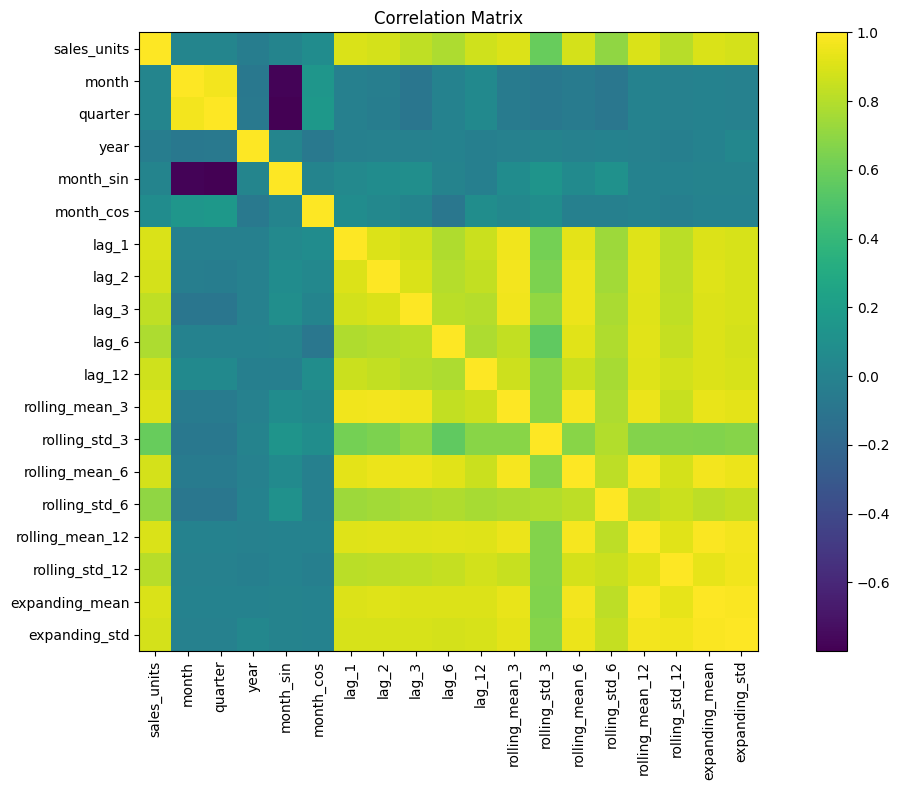

In [10]:
correlation = (
    feature_df
    .drop(columns=["date","category"])
    .corr()
)

plt.figure(figsize=(12,8))

plt.imshow(correlation)

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.show()

## Train-Test Split

In [11]:
train_df, test_df = pipeline.split_data(feature_df)

print("=" * 60)
print("TRAIN / TEST SPLIT")
print("=" * 60)

print(f"Training Shape : {train_df.shape}")
print(f"Testing Shape  : {test_df.shape}")

print("\nTraining Date Range")
print(train_df["date"].min(), "to", train_df["date"].max())

print("\nTesting Date Range")
print(test_df["date"].min(), "to", test_df["date"].max())

print("\nTraining Samples Per Category")
display(train_df.groupby("category").size())

print("\nTesting Samples Per Category")
display(test_df.groupby("category").size())

TRAIN / TEST SPLIT
Training Shape : (368, 21)
Testing Shape  : (96, 21)

Training Date Range
2015-01-31 00:00:00 to 2018-10-31 00:00:00

Testing Date Range
2018-11-30 00:00:00 to 2019-10-31 00:00:00

Training Samples Per Category


category
M01AB    46
M01AE    46
N02BA    46
N02BE    46
N05B     46
N05C     46
R03      46
R06      46
dtype: int64


Testing Samples Per Category


category
M01AB    12
M01AE    12
N02BA    12
N02BE    12
N05B     12
N05C     12
R03      12
R06      12
dtype: int64

# XGBoost Model Training

In [15]:
trainer = XGBoostTrainer()

trainer.fit(train_df)

predictions = trainer.predict(test_df)

In [16]:
mae = ForecastMetrics.mae(
    test_df["sales_units"],
    predictions
)

rmse = ForecastMetrics.rmse(
    test_df["sales_units"],
    predictions
)

mape = ForecastMetrics.mape(
    test_df["sales_units"],
    predictions
)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")

MAE  : 56.50
RMSE : 113.98
MAPE : 47.52%


In [17]:
results = test_df.copy()

results["Prediction"] = predictions

display(results.head())

,date,category,sales_units,month,quarter,year,month_sin,month_cos,lag_1,lag_2,...,lag_12,rolling_mean_3,rolling_std_3,rolling_mean_6,rolling_std_6,rolling_mean_12,rolling_std_12,expanding_mean,expanding_std,Prediction
368,2018-11-30,M01AB,172.290,11,4,2018,-0.5,0.866025,144.710,153.520,...,163.850,146.076667,6.862830,148.351667,7.906550,149.232500,12.833400,149.347759,30.490277,152.336792
369,2018-11-30,M01AE,105.487,11,4,2018,-0.5,0.866025,129.400,114.992,...,119.780,119.703667,8.398380,118.234667,10.816391,117.715667,9.712932,117.590828,24.232546,113.242287
370,2018-11-30,N02BA,102.150,11,4,2018,-0.5,0.866025,76.050,86.500,...,104.450,83.600000,6.596780,85.700000,4.845926,96.375000,14.729030,120.426879,30.067365,89.288551
371,2018-11-30,N02BE,995.150,11,4,2018,-0.5,0.866025,1129.275,1058.262,...,867.899,973.791667,210.817535,804.952667,230.021795,910.804500,218.462979,900.986707,336.655668,1009.454651
372,2018-11-30,N05B,252.200,11,4,2018,-0.5,0.866025,287.000,263.000,...,192.000,267.666667,17.473790,265.500000,15.996875,264.833333,46.189006,266.146552,89.461891,271.099976


In [18]:
results = test_df.copy()

results["Prediction"] = predictions

results["Error"] = results["sales_units"] - results["Prediction"]

results["Absolute Error"] = results["Error"].abs()

display(results.head(20))

,date,category,sales_units,month,quarter,year,month_sin,month_cos,lag_1,lag_2,...,rolling_std_3,rolling_mean_6,rolling_std_6,rolling_mean_12,rolling_std_12,expanding_mean,expanding_std,Prediction,Error,Absolute Error
368,2018-11-30,M01AB,172.290,11,4,2018,-5.000000e-01,0.866025,144.710,153.520,...,6.862830,148.351667,7.906550,149.232500,12.833400,149.347759,30.490277,152.336792,19.953208,19.953208
369,2018-11-30,M01AE,105.487,11,4,2018,-5.000000e-01,0.866025,129.400,114.992,...,8.398380,118.234667,10.816391,117.715667,9.712932,117.590828,24.232546,113.242287,-7.755287,7.755287
370,2018-11-30,N02BA,102.150,11,4,2018,-5.000000e-01,0.866025,76.050,86.500,...,6.596780,85.700000,4.845926,96.375000,14.729030,120.426879,30.067365,89.288551,12.861449,12.861449
371,2018-11-30,N02BE,995.150,11,4,2018,-5.000000e-01,0.866025,1129.275,1058.262,...,210.817535,804.952667,230.021795,910.804500,218.462979,900.986707,336.655668,1009.454651,-14.304651,14.304651
372,2018-11-30,N05B,252.200,11,4,2018,-5.000000e-01,0.866025,287.000,263.000,...,17.473790,265.500000,15.996875,264.833333,46.189006,266.146552,89.461891,271.099976,-18.899976,18.899976
373,2018-11-30,N05C,22.000,11,4,2018,-5.000000e-01,0.866025,25.000,12.000,...,6.557439,17.833333,4.792355,17.833333,9.232682,17.310345,8.842098,16.882080,5.117920,5.117920
374,2018-11-30,R03,311.000,11,4,2018,-5.000000e-01,0.866025,353.000,205.000,...,101.370607,183.333333,95.303025,205.833333,71.015790,155.038793,69.137922,217.610062,93.389938,93.389938
375,2018-11-30,R06,48.400,11,4,2018,-5.000000e-01,0.866025,76.900,88.100,...,13.145849,120.690000,48.620767,99.083333,57.152771,84.332931,44.048255,73.192047,-24.792047,24.792047
376,2018-12-31,M01AB,147.710,12,4,2018,-2.449294e-16,1.000000,172.290,144.710,...,14.086550,150.313333,11.953697,149.935833,13.894729,149.736610,30.373501,162.574600,-14.864600,14.864600
377,2018-12-31,M01AE,113.024,12,4,2018,-2.449294e-16,1.000000,105.487,129.400,...,12.039982,118.562167,10.299209,116.524583,10.295658,117.385678,24.074363,116.817581,-3.793581,3.793581


In [19]:
metrics = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "MAPE"],
    "Value": [mae, rmse, mape]
})

display(metrics)

,Metric,Value
0,MAE,56.502808
1,RMSE,113.979517
2,MAPE,47.523758


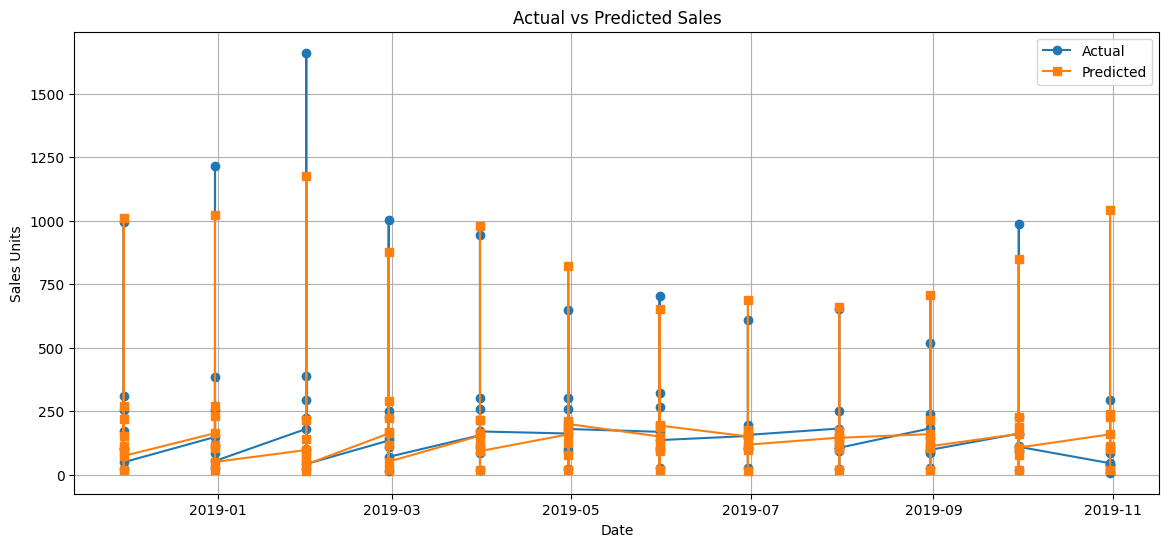

In [20]:
plt.figure(figsize=(14,6))

plt.plot(
    results["date"],
    results["sales_units"],
    marker="o",
    label="Actual"
)

plt.plot(
    results["date"],
    results["Prediction"],
    marker="s",
    label="Predicted"
)

plt.title("Actual vs Predicted Sales")

plt.xlabel("Date")

plt.ylabel("Sales Units")

plt.legend()

plt.grid(True)

plt.show()

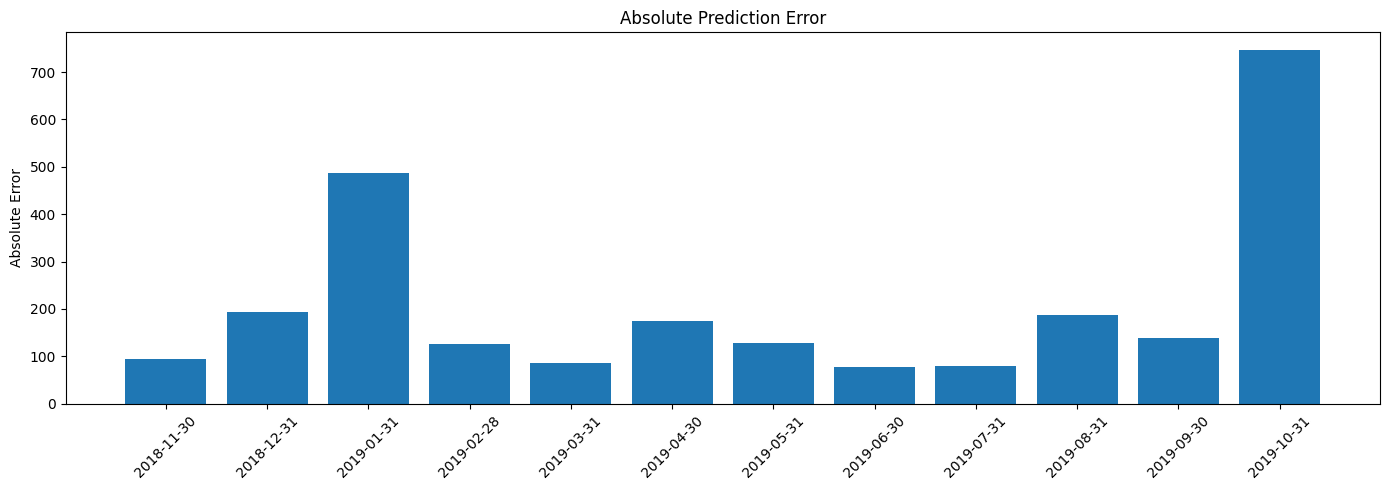

In [21]:
plt.figure(figsize=(14,5))

plt.bar(
    results["date"].astype(str),
    results["Absolute Error"]
)

plt.xticks(rotation=45)

plt.title("Absolute Prediction Error")

plt.ylabel("Absolute Error")

plt.tight_layout()

plt.show()

# Feature Importance

In [22]:
importance = pd.DataFrame({
    "Feature": trainer.feature_columns,
    "Importance": trainer.model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

display(importance)

,Feature,Importance
13,rolling_mean_6,0.562084
6,lag_1,0.109546
11,rolling_mean_3,0.067749
9,lag_6,0.039749
15,rolling_mean_12,0.039077
16,rolling_std_12,0.030413
8,lag_3,0.028549
5,month_cos,0.025357
18,expanding_std,0.020427
2,quarter,0.017438


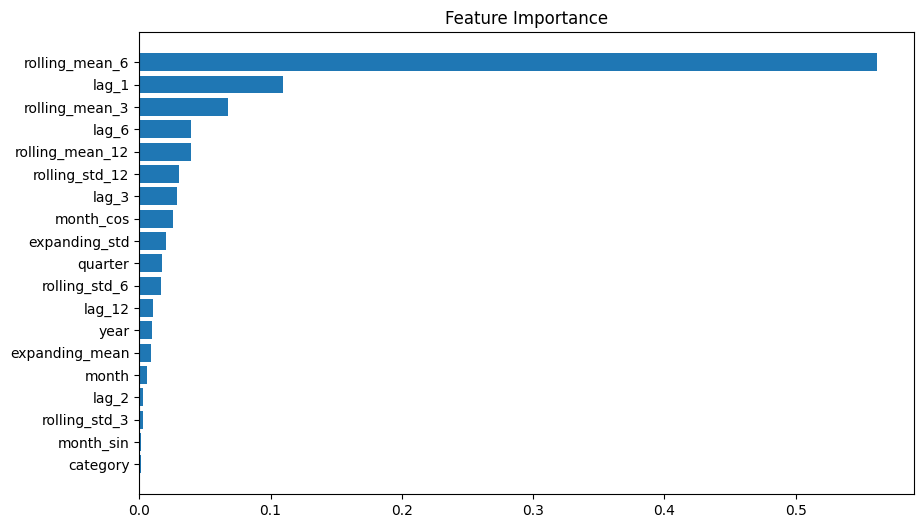

In [23]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance")

plt.gca().invert_yaxis()

plt.show()

# Future Forecasting

In [26]:
import pandas as pd

df = pd.read_csv("data/processed/global_predictions.csv")

df["date"] = pd.to_datetime(df["date"])

print(df.head(20))

print("\nColumns:")
print(df.columns)

print("\nShape:")
print(df.shape)

         date category  sales_units  month  quarter  year     month_sin  \
0  2018-11-30    M01AB      172.290     11        4  2018 -5.000000e-01   
1  2018-11-30    M01AE      105.487     11        4  2018 -5.000000e-01   
2  2018-11-30    N02BA      102.150     11        4  2018 -5.000000e-01   
3  2018-11-30    N02BE      995.150     11        4  2018 -5.000000e-01   
4  2018-11-30     N05B      252.200     11        4  2018 -5.000000e-01   
5  2018-11-30     N05C       22.000     11        4  2018 -5.000000e-01   
6  2018-11-30      R03      311.000     11        4  2018 -5.000000e-01   
7  2018-11-30      R06       48.400     11        4  2018 -5.000000e-01   
8  2018-12-31    M01AB      147.710     12        4  2018 -2.449294e-16   
9  2018-12-31    M01AE      113.024     12        4  2018 -2.449294e-16   
10 2018-12-31    N02BA       84.750     12        4  2018 -2.449294e-16   
11 2018-12-31    N02BE     1213.950     12        4  2018 -2.449294e-16   
12 2018-12-31     N05B   